# Clustering on incidence and socioeconomic data 

In [124]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import geopandas
import matplotlib.patches as mpatches

#this version of sklearn was throwing a bunch of runtime warnings, so this filters them out so the HTML notebook is still readable 
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


In [ ]:
#read in incidence data
incd = pd.read_csv('cancer_incidence_data_2023/cleaned_state_cancer_incd_data.csv', dtype={'FIPS': str})
incd.head()

,County,FIPS,Rural_Urban_Code,Age_Adjusted_Incd_Rate,Lower 95% Confidence Interval,Upper 95% Confidence Interval,Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,"Union County, Florida(2)",12125,Rural,1215.0,1144.9,1288.5,237,stable,0.3,-0.6,1.2
1,"Polk County, Texas(7)",48373,Rural,683.8,651.9,716.9,440,stable,-1.7,-3.9,0.8
2,"McPherson County, Nebraska(2)",31117,Rural,677.0,377.1,1145.8,4,*,*,*,*
3,"Dewey County, South Dakota(2)",46041,Rural,649.8,543.8,769.7,29,stable,1.4,-0.5,3.4
4,"Bracken County, Kentucky(7)",21023,Urban,621.8,555,695,68,stable,0.7,-0.6,2.1


In [30]:
#read in socioeconomic data
employment = pd.read_csv('USDA_economic_research_data/unemployment_2000s_cleaned.csv', dtype={'FIPS_Code': str})
edu = pd.read_csv('USDA_economic_research_data/education_2000s_cleaned.csv', dtype={'FIPS Code': str})

In [31]:
print(incd.shape)
print(employment.shape)
print(edu.shape)

(3143, 11)
(3269, 4)
(3267, 13)


In [32]:
#FIPS Code -> FIPS for the socioeconomic data
employment = employment.rename(columns={'FIPS_Code': 'FIPS'})
edu = edu.rename(columns={'FIPS Code': 'FIPS'})
#woops think theres a space in the incd FIPS column, so rename that too
incd = incd.rename(columns={'FIPS ': 'FIPS'})


In [39]:
#join on FIPS

joined = incd.merge(employment, on="FIPS", how="inner")
joined = joined.merge(edu, on="FIPS", how="inner")


In [34]:
joined.head()

,County,FIPS,Rural_Urban_Code,Age_Adjusted_Incd_Rate,Lower 95% Confidence Interval,Upper 95% Confidence Interval,Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,...,Decade_y,Year,Percent of adults completing some college or associate degree,Percent of adults completing some college or associate degree-12,Percent of adults who are high school graduates (or equivalent),Percent of adults who are high school graduates (or equivalent)-12,Percent of adults who are not high school graduates,Percent of adults who are not high school graduates-12,Percent of adults with a bachelor's degree or higher,Percent of adults with a bachelor's degree or higher-12
0,"Union County, Florida(2)",12125,Rural,1215.0,1144.9,1288.5,237,stable,0.3,-0.6,...,2000,2004.0,26.1,26.484102,38.9,38.200698,27.5,25.170006,7.5,10.145194
1,"Polk County, Texas(7)",48373,Rural,683.8,651.9,716.9,440,stable,-1.7,-3.9,...,2000,2004.0,23.1,29.941824,36.5,35.174527,30.0,22.858646,10.4,12.025003
2,"McPherson County, Nebraska(2)",31117,Rural,677.0,377.1,1145.8,4,*,*,*,...,2000,2004.0,26.7,42.105263,39.7,26.315789,11.4,6.666667,22.2,24.912281
3,"Dewey County, South Dakota(2)",46041,Rural,649.8,543.8,769.7,29,stable,1.4,-0.5,...,2000,2004.0,33.1,31.493397,32.2,36.302066,22.6,17.947850,12.2,14.256688
4,"Bracken County, Kentucky(7)",21023,Urban,621.8,555,695,68,stable,0.7,-0.6,...,2000,2004.0,19.5,22.742594,40.6,40.039028,30.4,22.334575,9.5,14.883803


In [35]:
joined.isna().sum()

County                                                                  0
FIPS                                                                    0
Rural_Urban_Code                                                        0
Age_Adjusted_Incd_Rate                                                113
Lower 95% Confidence Interval                                           0
Upper 95% Confidence Interval                                           0
Average Annual Count                                                    0
Recent Trend                                                            0
Recent 5-Year Trend ([trend note]) in Incidence Rates                   0
Lower 95% Confidence Interval.1                                         0
Upper 95% Confidence Interval.1                                         0
State_x                                                                 0
Decade_x                                                                0
Unemployment_rate_                    

In [40]:
#looks like we have 113 counties without incidence data, so let's drop those
joined.dropna(subset=['Age_Adjusted_Incd_Rate'], inplace=True)

In [37]:
print(joined.shape)
joined.isna().sum()


(3022, 26)


County                                                                0
FIPS                                                                  0
Rural_Urban_Code                                                      0
Age_Adjusted_Incd_Rate                                                0
Lower 95% Confidence Interval                                         0
Upper 95% Confidence Interval                                         0
Average Annual Count                                                  0
Recent Trend                                                          0
Recent 5-Year Trend ([trend note]) in Incidence Rates                 0
Lower 95% Confidence Interval.1                                       0
Upper 95% Confidence Interval.1                                       0
State_x                                                               0
Decade_x                                                              0
Unemployment_rate_                                              

In [41]:
joined.drop(columns=['Recent Trend', 'State_x', 'State_y', 'Decade_x', 'Decade_y', 'Year', 'Area name', 'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval', 'Lower 95% Confidence Interval.1', 'Upper 95% Confidence Interval.1'], inplace=True)
#looks like some columns got duplicated in the merge, so drop those
joined.drop(columns=["Percent of adults completing some college or associate degree-12", 
                "Percent of adults who are high school graduates (or equivalent)-12", 
                     "Percent of adults who are not high school graduates-12", 
                     "Percent of adults with a bachelor's degree or higher-12"], inplace=True)
joined = joined.drop(columns="Recent 5-Year Trend ([trend note]) in Incidence Rates")
joined = joined.drop(columns="County")
joined = joined.drop(columns="Rural_Urban_Code")
joined = joined.drop(columns='Average Annual Count')



In [42]:
#to run clustering, data must be numeric and have no missing values
joined.dtypes

FIPS                                                                object
Age_Adjusted_Incd_Rate                                             float64
Unemployment_rate_                                                 float64
Percent of adults completing some college or associate degree      float64
Percent of adults who are high school graduates (or equivalent)    float64
Percent of adults who are not high school graduates                float64
Percent of adults with a bachelor's degree or higher               float64
dtype: object

In [43]:
joined.isna().sum()

FIPS                                                               0
Age_Adjusted_Incd_Rate                                             0
Unemployment_rate_                                                 0
Percent of adults completing some college or associate degree      0
Percent of adults who are high school graduates (or equivalent)    0
Percent of adults who are not high school graduates                0
Percent of adults with a bachelor's degree or higher               0
dtype: int64

In [44]:
joined.head()

,FIPS,Age_Adjusted_Incd_Rate,Unemployment_rate_,Percent of adults completing some college or associate degree,Percent of adults who are high school graduates (or equivalent),Percent of adults who are not high school graduates,Percent of adults with a bachelor's degree or higher
0,12125,1215.0,3.75,26.1,38.9,27.5,7.5
1,48373,683.8,6.94,23.1,36.5,30.0,10.4
2,31117,677.0,2.19,26.7,39.7,11.4,22.2
3,46041,649.8,9.00,33.1,32.2,22.6,12.2
4,21023,621.8,6.24,19.5,40.6,30.4,9.5


In [81]:
#standardize the data (incidence per 100k and percentages are pretty different scales)
scaled_data = StandardScaler().fit_transform(joined)

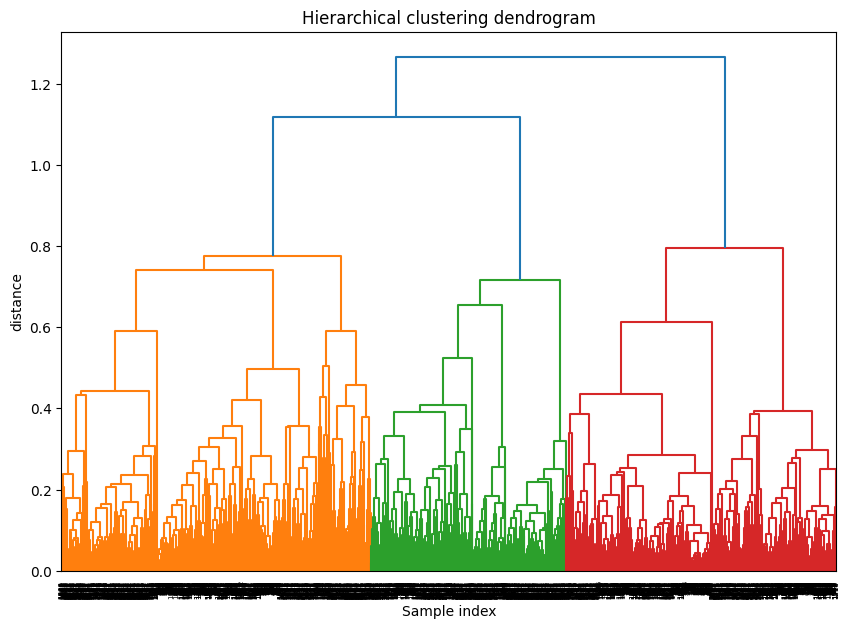

In [98]:
# heirarchical clustering with cosine distance
linked = linkage(scaled_data, method='average', metric='cosine')

#plotting the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Hierarchical clustering dendrogram')
plt.xlabel('Sample index')
plt.ylabel('distance')
plt.show()

In [116]:
#need FIPS to merge with geospatial data, so reset index
#joined = joined.reset_index()


In [125]:
#sillhouette method for kmeans 
score_dict = {}

for k in range(2, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    score_dict[k] = score



In [123]:
for k, score in score_dict.items():
    print(f'k={k}: silhouette score={score}')

max_score = max(score_dict, key=score_dict.get)
print(f'max score is for  {max_score} clusters')

k=2: silhouette score=0.2569397154170715
k=3: silhouette score=0.29509093690672084
k=4: silhouette score=0.304963090733193
k=5: silhouette score=0.279618916493769
k=6: silhouette score=0.30418344765927313
k=7: silhouette score=0.3298389587435327
k=8: silhouette score=0.3386303409971199
k=9: silhouette score=0.3206566595708129
k=10: silhouette score=0.2898428530014398
k=11: silhouette score=0.24913134068614348
max score is for  8 clusters


In [126]:

#based on the dendrogram and the silhouete scorees, let's try 3, 5, and 8 
km = KMeans(n_clusters=3, random_state=42, n_init=10)
joined['Cluster 1'] = km.fit_predict(scaled_data)
km = KMeans(n_clusters=5, random_state=42, n_init=10)
joined['Cluster 2'] = km.fit_predict(scaled_data)
km = KMeans(n_clusters=8, random_state=42, n_init=10)
joined['Cluster 3'] = km.fit_predict(scaled_data)


#all the resultant runtime warning are apparently due to the version of sklearn, and not actually an issue with the code

/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T/ipykernel_4458/3179645356.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(n_clusters))
/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T/ipykernel_4458/3179645356.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(n_clusters))
/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T/ipykernel_4458/3179645356.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()

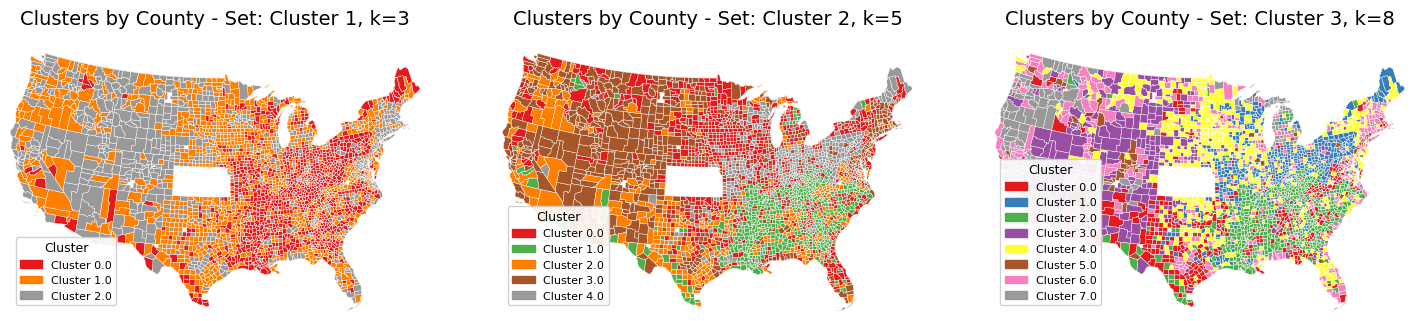

In [ ]:

#grab the code from the EDA for map plotting, and color the counties by cluster labels 
#then we;ll iterate to make 3 subplots , fort each cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, cluster_col in enumerate(['Cluster 1', 'Cluster 2', 'Cluster 3']):
    gdf = geopandas.read_file('cancer_incidence_data_2023/cb_2018_us_county_20m/cb_2018_us_county_20m.shp')
    gdf = gdf.rename(columns={'GEOID': 'FIPS'})
    gdf = gdf.merge(joined[['FIPS', cluster_col]], on='FIPS', how='left')
    gdf = gdf.to_crs("EPSG:5070") 
    conus = gdf[~gdf['STATEFP'].isin(['02', '15', '72'])]  #remove ak, hi, and PR to make viz easier
    conus_bounds = conus.total_bounds
    conus = conus.copy()
    conus[cluster_col] = conus[cluster_col].astype('category')
    n_clusters = conus[cluster_col].cat.categories
    cmap = plt.cm.get_cmap('Set1', len(n_clusters))
    ax = axes[i]
    conus.plot(
        column=cluster_col,
        ax=ax,
        cmap=cmap,
        legend=False,
        edgecolor='white',
        linewidth=0.3)
    ax.set_xlim(conus_bounds[[0, 2]])
    ax.set_ylim(conus_bounds[[1, 3]])
    ax.set_title(f'Clusters by County - Set: {cluster_col}, k={len(n_clusters)}', fontsize=14, pad=10)
    ax.set_axis_off()
    patches = [
        mpatches.Patch(color=cmap(i), label=f'Cluster {cat}')
        for i, cat in enumerate(n_clusters)
    ]
    ax.legend( handles=patches, title='Cluster', loc='lower left', fontsize=8, title_fontsize=9,
        framealpha=0.9)

In [120]:
#what do the clusters look like in terms of feature profiles? 
#i.e. what are the mean feature values of each cluster?
#only the numeric columns- we can ignore the FIPS columns, and we don't need the means for the cluster labels, so we can ignore those too
clust_means_1 = joined.groupby('Cluster 1').mean(numeric_only=True)
clust_means_1 = clust_means_1.drop(columns=['Cluster', 'Cluster 2', 'Cluster 3'])
print(clust_means_1)
clust_means_2 = joined.groupby('Cluster 2').mean(numeric_only=True)
clust_means_2 = clust_means_2.drop(columns=['Cluster', 'Cluster 1', 'Cluster 3'])
print(clust_means_2)

clust_means_3 = joined.groupby('Cluster 3').mean(numeric_only=True)
clust_means_3 = clust_means_3.drop(columns=['Cluster', 'Cluster 1', 'Cluster 2'])
print(clust_means_3)

               level_0        index  Age_Adjusted_Incd_Rate  \
Cluster 1                                                     
0          1101.078822  1101.078822              486.073219   
1          1503.826599  1503.826599              459.606987   
2          2072.661972  2072.661972              420.656594   

           Unemployment_rate_  \
Cluster 1                       
0                    6.986213   
1                    5.507096   
2                    4.595285   

           Percent of adults completing some college or associate degree  \
Cluster 1                                                                  
0                                                  20.974074               
1                                                  27.363047               
2                                                  30.581434               

           Percent of adults who are high school graduates (or equivalent)  \
Cluster 1                                                  

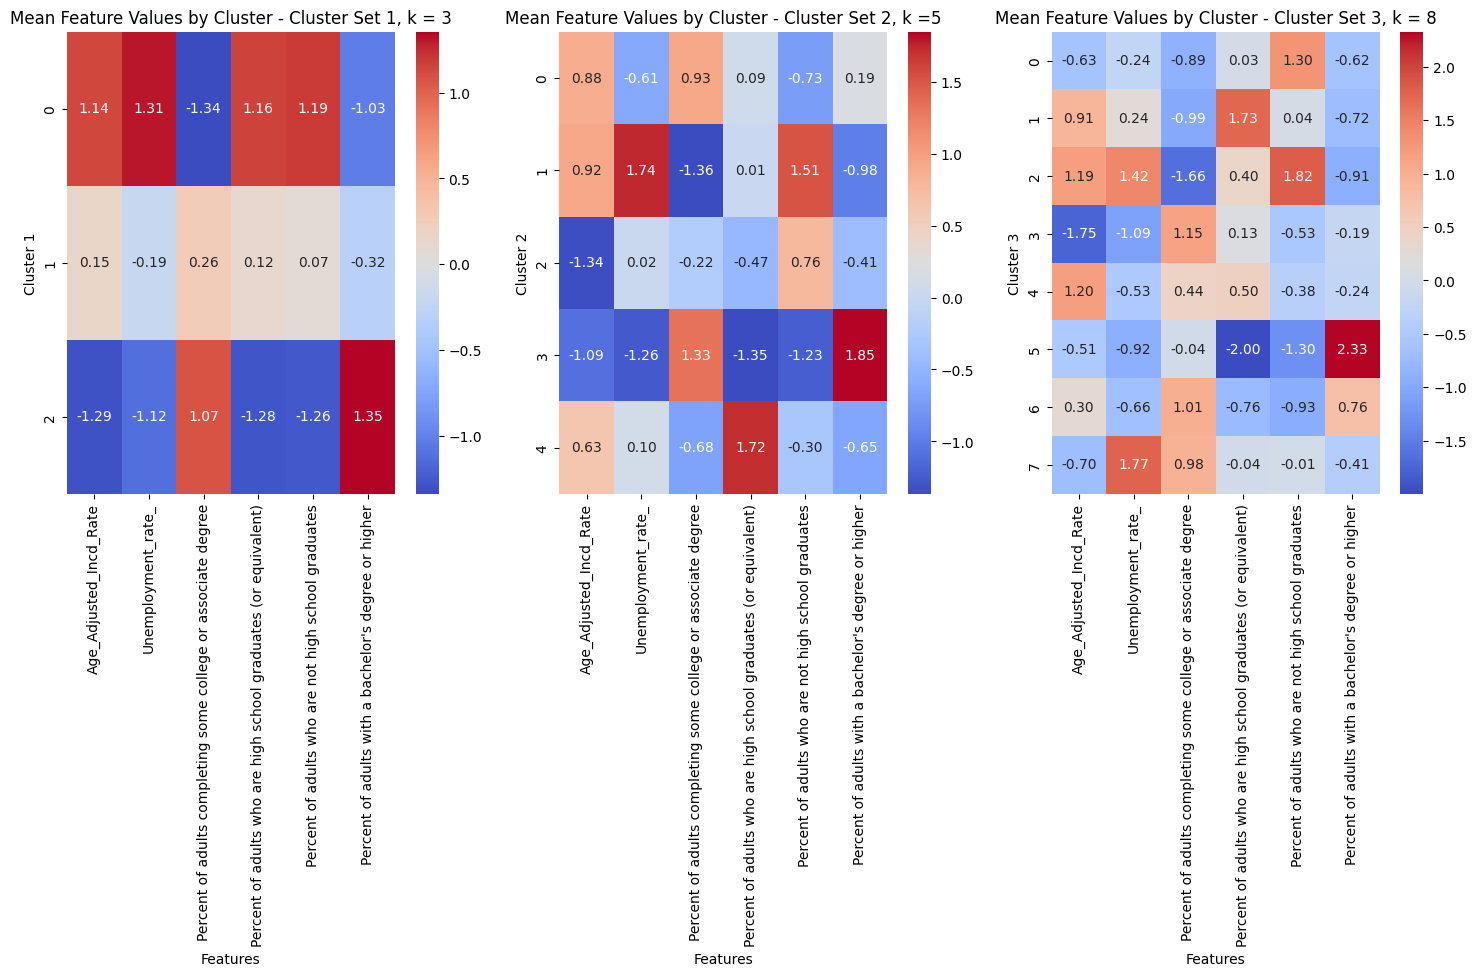

In [121]:

#scale clusters means for better visualization
clust_means_scaled_1 = StandardScaler().fit_transform(clust_means_1)
clust_means_scaled_1_df = pd.DataFrame(clust_means_scaled_1, index=clust_means_1.index, columns=clust_means_1.columns)
clust_means_scaled_2 = StandardScaler().fit_transform(clust_means_2)
clust_means_scaled_2_df = pd.DataFrame(clust_means_scaled_2, index=clust_means_2.index, columns=clust_means_2.columns)
clust_means_scaled_3 = StandardScaler().fit_transform(clust_means_3)
clust_means_scaled_3_df = pd.DataFrame(clust_means_scaled_3, index=clust_means_3.index, columns=clust_means_3.columns)

#drop the index column for the heatmaps, since we don't need the cluster labels on the y-axis
clust_means_scaled_1_df = clust_means_scaled_1_df.drop(columns=['level_0', 'index'])
clust_means_scaled_2_df = clust_means_scaled_2_df.drop(columns=['level_0', 'index'])
clust_means_scaled_3_df = clust_means_scaled_3_df.drop(columns=['level_0', 'index'])

#visualize the cluster profiles with a heatmap and subplots. 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.heatmap(clust_means_scaled_1_df, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Mean Feature Values by Cluster - Cluster Set 1, k = 3')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Cluster 1')
axes[0].tick_params(axis='x', rotation=90)
sns.heatmap(clust_means_scaled_2_df, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Mean Feature Values by Cluster - Cluster Set 2, k =5')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Cluster 2')
axes[1].tick_params(axis='x', rotation=90)
sns.heatmap(clust_means_scaled_3_df, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Mean Feature Values by Cluster - Cluster Set 3, k = 8')
axes[2].set_xlabel('Features')
axes[2].set_ylabel('Cluster 3')
axes[2].tick_params(axis='x', rotation=90)
plt.show()




